# eCourts Uttarakhand High Court - DVI TASK

Name- Aastha Baheti
Batch- 2
SAP ID- 590012973

**Dataset:** https://docs.google.com/spreadsheets/d/165WVbl0FhQSZE4wY_WyaN4JTbDAczP4n/edit?usp=sharing&ouid=109510708223827697266&rtpof=true&sd=true

**Source:** https://hcservices.ecourts.gov.in/ecourtindiaHC/



#Load & Clean Data

In [11]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

df = pd.read_excel('ecourts_dataset.xlsx', sheet_name='Case Data')

col = 'Case Type/Case Number/Case Year'
df['Case Code']       = df[col].str.extract(r'^([A-Z0-9]+)')
df['Case Year']       = pd.to_numeric(df[col].str.extract(r'/(\d{4})$')[0], errors='coerce')
df['Case Number Num'] = pd.to_numeric(df[col].str.extract(r'/(\d+)/\d{4}$')[0], errors='coerce')
df['Search Label']    = df['_search'].astype(str).str.strip("'\" ")

party_col = 'Petitioner Name Versus Respondent Name'
df['Petitioner'] = df[party_col].str.split(r'\\nVersus\\n|Versus').str[0].str.strip()
df['Respondent'] = df[party_col].str.split(r'\\nVersus\\n|Versus').str[-1].str.strip()

print(f'Rows loaded : {len(df)}')
print(f'Columns     : {list(df.columns)}')
print(f'Year range  : {int(df["Case Year"].min())} - {int(df["Case Year"].max())}')
print(f'Search types: {df["Search Label"].unique()}')
df.head(3)

Rows loaded : 1919
Columns     : ['Sr No', 'Case Type/Case Number/Case Year', 'Petitioner Name Versus Respondent Name', 'View', 'Order Date', 'Order Number', '_table', '_search', '_page', '_time', 'Case Code', 'Case Year', 'Case Number Num', 'Search Label', 'Petitioner', 'Respondent']
Year range  : 2004 - 2026
Search types: ['First Bail Application' 'Petitioner/Respondant - Uttrakhand'
 '10/09/2026-15/09/2026']


,Sr No,Case Type/Case Number/Case Year,Petitioner Name Versus Respondent Name,View,Order Date,Order Number,_table,_search,_page,_time,Case Code,Case Year,Case Number Num,Search Label,Petitioner,Respondent
0,1,BA1/1570/2026,PARTH\nVersus\nSTATE OF UTTARAKHAND,Viewdetails for case number BA1/1570/2026,NaN,NaN,0,'First Bail Application',1,2026-09-16 13:04:30,BA1,2026,1570,First Bail Application,PARTH,STATE OF UTTARAKHAND
1,2,BA1/1569/2026,NIKHIL VERMA\nVersus\nSTATE OF UTTARAKHAND,Viewdetails for case number BA1/1569/2026,NaN,NaN,0,'First Bail Application',1,2026-09-16 13:04:30,BA1,2026,1569,First Bail Application,NIKHIL VERMA,STATE OF UTTARAKHAND
2,3,BA1/1568/2026,WASEEM\nVersus\nSTATE OF UTTARAKHAND,Viewdetails for case number BA1/1568/2026,NaN,NaN,0,'First Bail Application',1,2026-09-16 13:04:30,BA1,2026,1568,First Bail Application,WASEEM,STATE OF UTTARAKHAND


#Horizontal Bar — Cases by Search Category

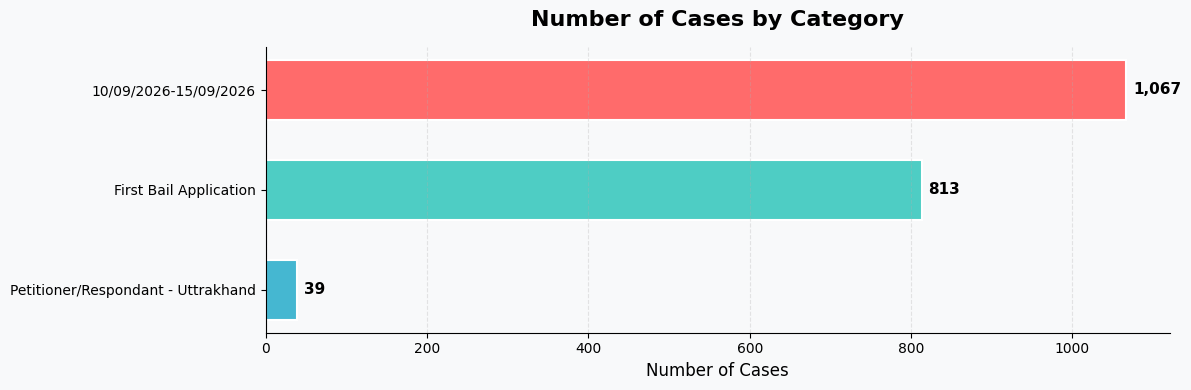

In [12]:

counts = df['Search Label'].value_counts()

COLORS = ['#FF6B6B','#4ECDC4','#45B7D1','#96CEB4','#FFEAA7',
          '#DDA0DD','#98D8C8','#F7DC6F','#BB8FCE','#82E0AA']

fig, ax = plt.subplots(figsize=(12, max(4, len(counts)*0.8)))
bars = ax.barh(counts.index, counts.values,
               color=COLORS[:len(counts)], edgecolor='white', linewidth=1.5, height=0.6)
for bar, val in zip(bars, counts.values):
    ax.text(val + 8, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontweight='bold', fontsize=11)
ax.set_xlabel('Number of Cases', fontsize=12)
ax.set_title('Number of Cases by Category', fontsize=16, fontweight='bold', pad=15)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
fig.patch.set_facecolor('#F8F9FA')
ax.set_facecolor('#F8F9FA')
plt.tight_layout()
plt.show()

# Pie Chart — Case Type Distribution

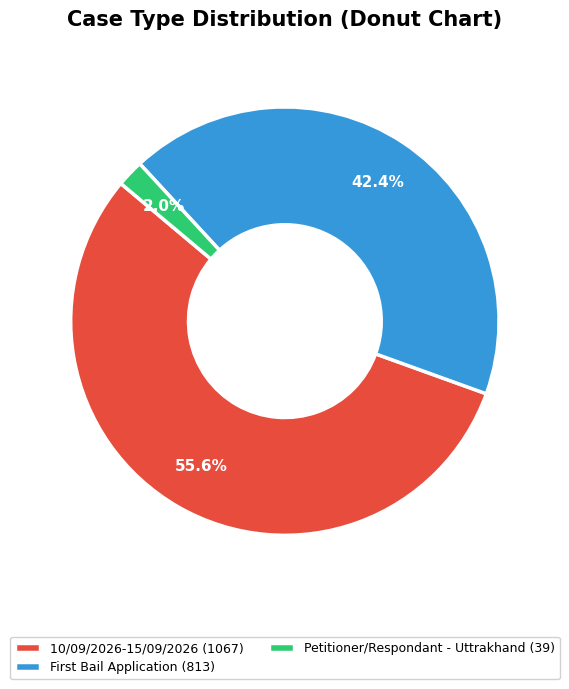

In [13]:

DONUT_COLORS = ['#E74C3C','#3498DB','#2ECC71','#F39C12',
                '#9B59B6','#1ABC9C','#E67E22','#34495E']

fig, ax = plt.subplots(figsize=(9, 7))
wedges, texts, autotexts = ax.pie(
    counts.values,
    labels=None,
    autopct='%1.1f%%',
    colors=DONUT_COLORS[:len(counts)],
    startangle=140,
    pctdistance=0.78,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2.5)  # donut
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight('bold')
    at.set_color('white')
ax.legend(wedges, [f'{l} ({v})' for l,v in zip(counts.index, counts.values)],
          loc='lower center', bbox_to_anchor=(0.5, -0.18),
          ncol=2, fontsize=9, framealpha=0.9)
ax.set_title('Case Type Distribution (Donut Chart)',
             fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

#  Bar Chart — Cases Filed Per Year

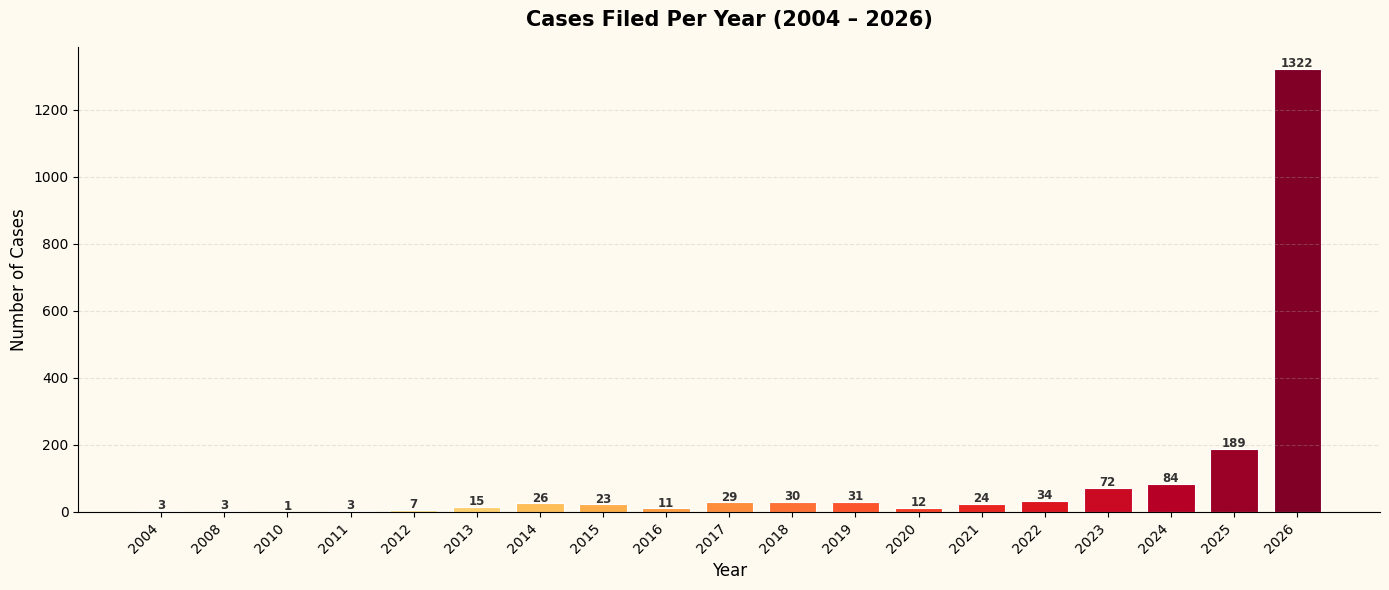

In [14]:

year_counts = df['Case Year'].dropna().astype(int).value_counts().sort_index()

# Gradient colour: light orange to deep red
n = len(year_counts)
cmap = plt.cm.get_cmap('YlOrRd', n)
bar_colors = [cmap(i/n) for i in range(n)]

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(year_counts.index.astype(str), year_counts.values,
              color=bar_colors, edgecolor='white', linewidth=0.8, width=0.75)
for bar, val in zip(bars, year_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(val), ha='center', fontsize=8.5, fontweight='bold', color='#333')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Cases', fontsize=12)
ax.set_title('Cases Filed Per Year (2004 – 2026)', fontsize=15, fontweight='bold', pad=15)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(rotation=45, ha='right')
fig.patch.set_facecolor('#FFFAF0')
ax.set_facecolor('#FFFAF0')
plt.tight_layout()
plt.show()

# Area Chart — Cumulative Cases Over Years

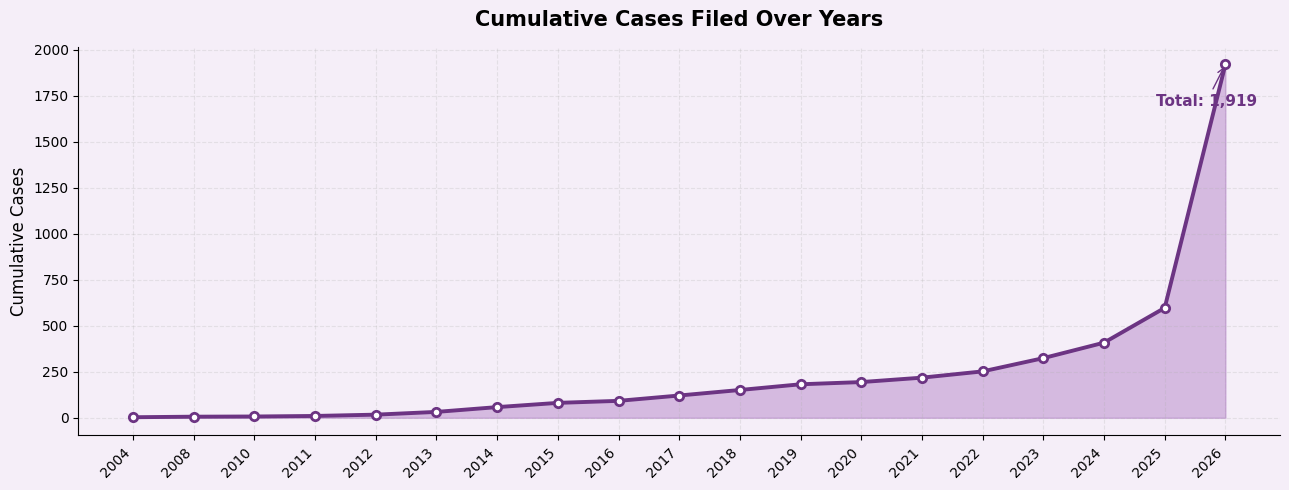

In [15]:

cumulative = year_counts.cumsum()

fig, ax = plt.subplots(figsize=(13, 5))
x = cumulative.index.astype(str)
y = cumulative.values

ax.fill_between(range(len(x)), y, color='#9B59B6', alpha=0.35, label='Cumulative Cases')
ax.plot(range(len(x)), y, color='#6C3483', linewidth=2.8,
        marker='o', markersize=6, markerfacecolor='white',
        markeredgecolor='#6C3483', markeredgewidth=2)

# Annotate last point
ax.annotate(f'Total: {y[-1]:,}', xy=(len(x)-1, y[-1]),
            xytext=(-50, -30), textcoords='offset points',
            fontsize=11, fontweight='bold', color='#6C3483',
            arrowprops=dict(arrowstyle='->', color='#6C3483'))

ax.set_xticks(range(len(x)))
ax.set_xticklabels(x, rotation=45, ha='right')
ax.set_ylabel('Cumulative Cases', fontsize=12)
ax.set_title('Cumulative Cases Filed Over Years', fontsize=15, fontweight='bold', pad=15)
ax.grid(alpha=0.25, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
fig.patch.set_facecolor('#F5EEF8')
ax.set_facecolor('#F5EEF8')
plt.tight_layout()
plt.show()

#  Stacked Bar — Case Type Breakdown Per Year

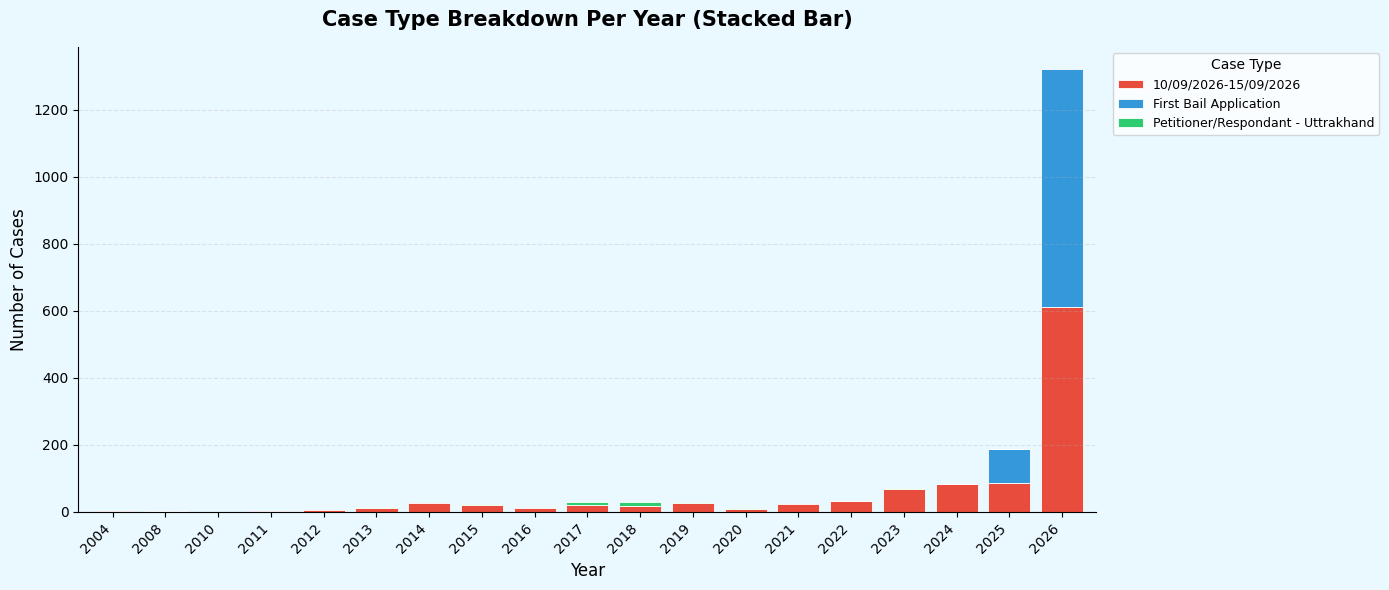

In [16]:

pivot = df.dropna(subset=['Case Year']).copy()
pivot['Case Year'] = pivot['Case Year'].astype(int)
pivot_table = pivot.groupby(['Case Year','Search Label']).size().unstack(fill_value=0)

STACK_COLORS = ['#E74C3C','#3498DB','#2ECC71','#F39C12','#9B59B6',
                '#1ABC9C','#E67E22','#34495E','#E91E63','#00BCD4']

fig, ax = plt.subplots(figsize=(14, 6))
pivot_table.plot(kind='bar', stacked=True, ax=ax,
                 color=STACK_COLORS[:len(pivot_table.columns)],
                 edgecolor='white', linewidth=0.6, width=0.8)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Cases', fontsize=12)
ax.set_title('Case Type Breakdown Per Year (Stacked Bar)',
             fontsize=15, fontweight='bold', pad=15)
ax.legend(title='Case Type', bbox_to_anchor=(1.01, 1),
          loc='upper left', fontsize=9)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(rotation=45, ha='right')
fig.patch.set_facecolor('#EAF8FF')
ax.set_facecolor('#EAF8FF')
plt.tight_layout()
plt.show()

#Heatmap — Case Type × Year

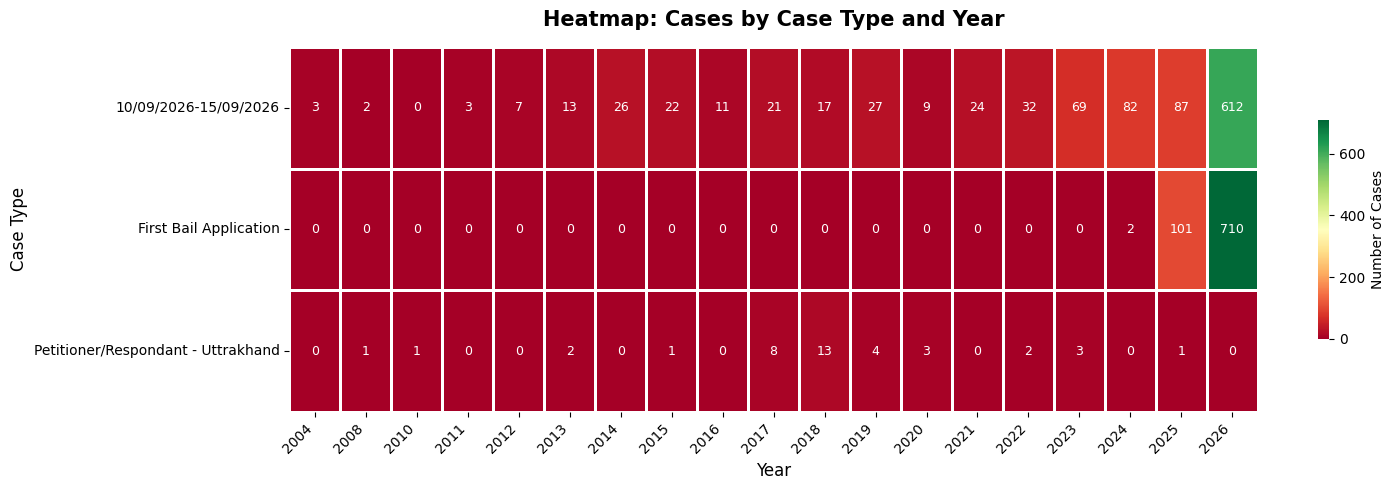

In [17]:

fig, ax = plt.subplots(figsize=(max(10, len(pivot_table)*0.8),
                                max(5, len(pivot_table.columns)*1.2)))
sns.heatmap(
    pivot_table.T,
    annot=True, fmt='d',
    cmap='RdYlGn',          # Red -> Yellow -> Green
    linewidths=0.8,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Number of Cases', 'shrink': 0.6},
    annot_kws={'size': 9}
)
ax.set_title('Heatmap: Cases by Case Type and Year',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Case Type', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

#  Box Plot — Case Number Distribution by Type

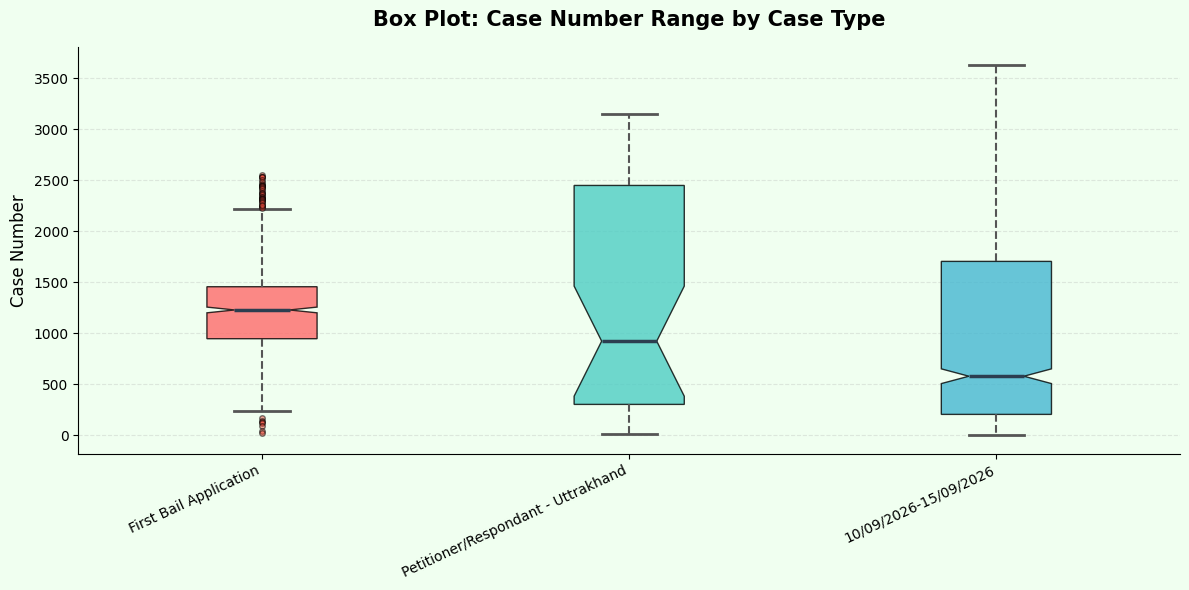

In [18]:

box_data    = df.dropna(subset=['Case Number Num'])
labels_ord  = (box_data.groupby('Search Label')['Case Number Num']
               .median().sort_values(ascending=False).index.tolist())
data_groups = [box_data[box_data['Search Label']==l]['Case Number Num'].values
               for l in labels_ord]

BOX_COLORS = ['#FF6B6B','#4ECDC4','#45B7D1','#96CEB4',
              '#FFEAA7','#DDA0DD','#F0E68C','#87CEEB']

fig, ax = plt.subplots(figsize=(12, 6))
bp = ax.boxplot(data_groups,
                tick_labels=labels_ord,
                patch_artist=True,
                notch=True,
                medianprops=dict(color='#2C3E50', linewidth=2.5),
                whiskerprops=dict(color='#555', linewidth=1.5, linestyle='--'),
                capprops=dict(color='#555', linewidth=2),
                flierprops=dict(marker='o', markerfacecolor='#E74C3C',
                                markersize=4, alpha=0.5))
for patch, color in zip(bp['boxes'], BOX_COLORS[:len(labels_ord)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax.set_ylabel('Case Number', fontsize=12)
ax.set_title('Box Plot: Case Number Range by Case Type',
             fontsize=15, fontweight='bold', pad=15)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
fig.patch.set_facecolor('#F0FFF0')
ax.set_facecolor('#F0FFF0')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

#  Scatter Plot — Case Number vs Year

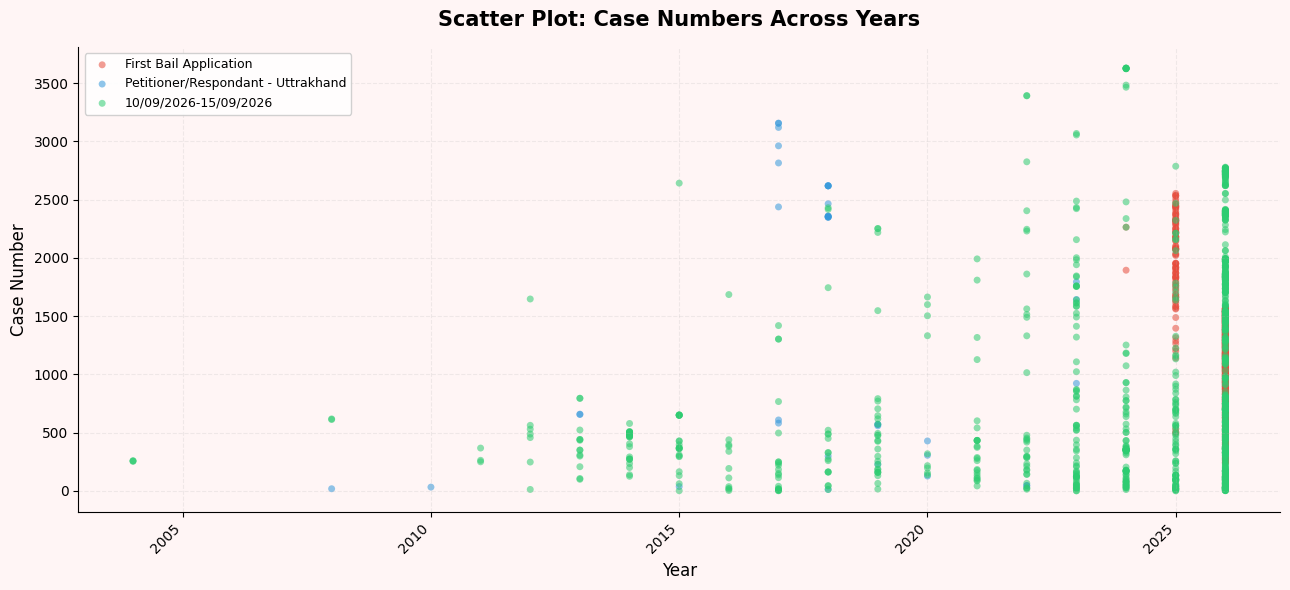

In [19]:

sc = df.dropna(subset=['Case Number Num','Case Year']).copy()
sc['Case Year'] = sc['Case Year'].astype(int)

SCATTER_COLORS = {'First Bail Application':       '#E74C3C',
                  'Petitioner/Respondant - Uttrakhand': '#3498DB',
                  '10/09/2026-15/09/2026':         '#2ECC71'}

fig, ax = plt.subplots(figsize=(13, 6))
for label in sc['Search Label'].unique():
    sub = sc[sc['Search Label'] == label]
    color = SCATTER_COLORS.get(label, '#F39C12')
    ax.scatter(sub['Case Year'], sub['Case Number Num'],
               label=label, color=color,
               alpha=0.55, s=25, edgecolors='none')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Case Number', fontsize=12)
ax.set_title('Scatter Plot: Case Numbers Across Years',
             fontsize=15, fontweight='bold', pad=15)
ax.legend(fontsize=9, framealpha=0.9)
ax.grid(alpha=0.2, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
fig.patch.set_facecolor('#FFF5F5')
ax.set_facecolor('#FFF5F5')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#  Horizontal Bar — Top 20 Petitioners

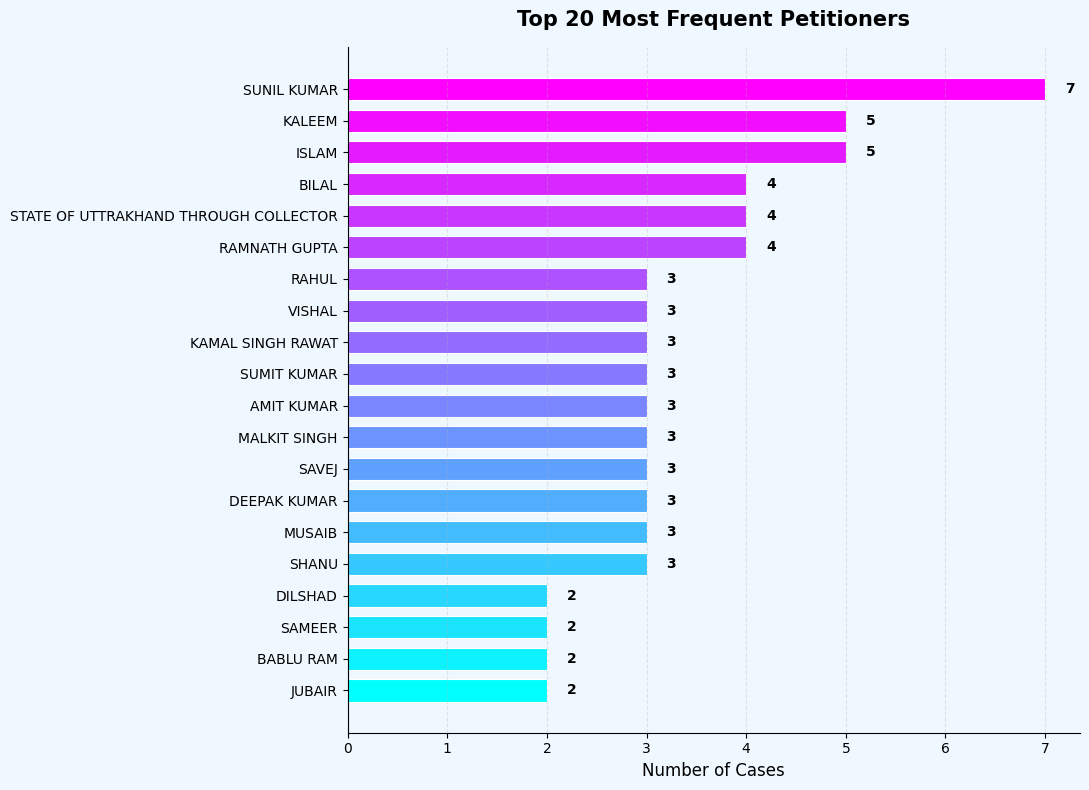

In [20]:

pet = (df['Petitioner'].dropna()
       .str.upper().str.strip()
       .replace('', np.nan).dropna()
       .value_counts().head(20))

# Teal-to-purple gradient
cmap2 = plt.cm.get_cmap('cool', len(pet))
bar_c = [cmap2(i/len(pet)) for i in range(len(pet))]

fig, ax = plt.subplots(figsize=(11, 8))
bars = ax.barh(pet.index[::-1], pet.values[::-1],
               color=bar_c, edgecolor='white', linewidth=0.8, height=0.7)
for bar, val in zip(bars, pet.values[::-1]):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=10, fontweight='bold')
ax.set_xlabel('Number of Cases', fontsize=12)
ax.set_title('Top 20 Most Frequent Petitioners',
             fontsize=15, fontweight='bold', pad=15)
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
fig.patch.set_facecolor('#F0F8FF')
ax.set_facecolor('#F0F8FF')
plt.tight_layout()
plt.show()

# Line Chart — Year-wise Trend per Case Type

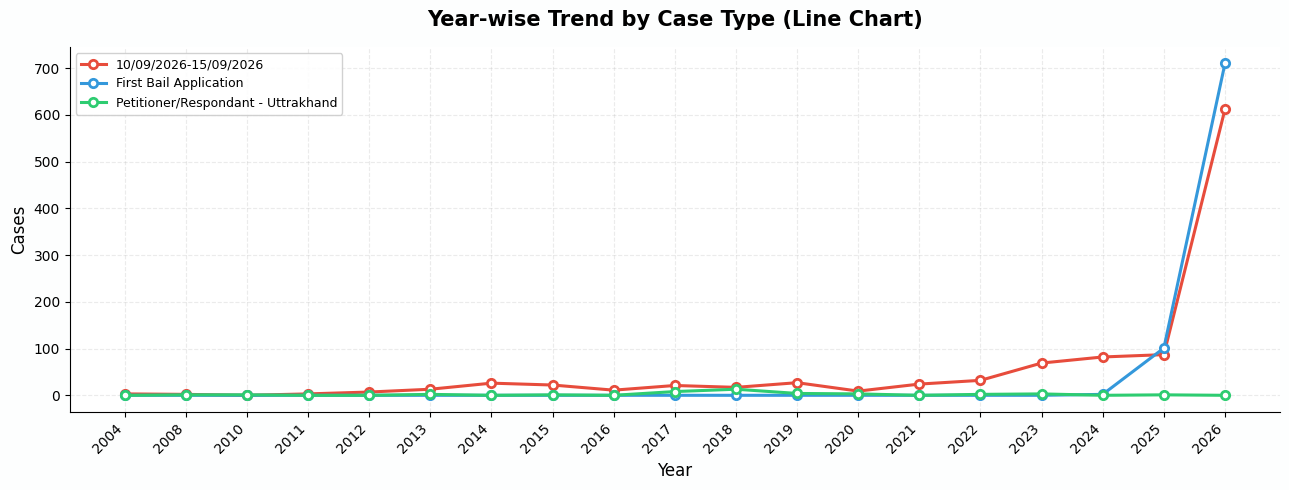

In [21]:

LINE_COLORS = ['#E74C3C','#3498DB','#2ECC71','#F39C12','#9B59B6']

fig, ax = plt.subplots(figsize=(13, 5))
for i, label in enumerate(pivot_table.columns):
    color = LINE_COLORS[i % len(LINE_COLORS)]
    ax.plot(pivot_table.index.astype(str), pivot_table[label],
            marker='o', markersize=6, linewidth=2.2,
            color=color, label=label,
            markerfacecolor='white', markeredgewidth=2,
            markeredgecolor=color)

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Cases', fontsize=12)
ax.set_title('Year-wise Trend by Case Type (Line Chart)',
             fontsize=15, fontweight='bold', pad=15)
ax.legend(fontsize=9, framealpha=0.9)
ax.grid(alpha=0.25, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(rotation=45, ha='right')
fig.patch.set_facecolor('#FDFEFE')
plt.tight_layout()
plt.show()

#  Violin Plot — Case Number by Type

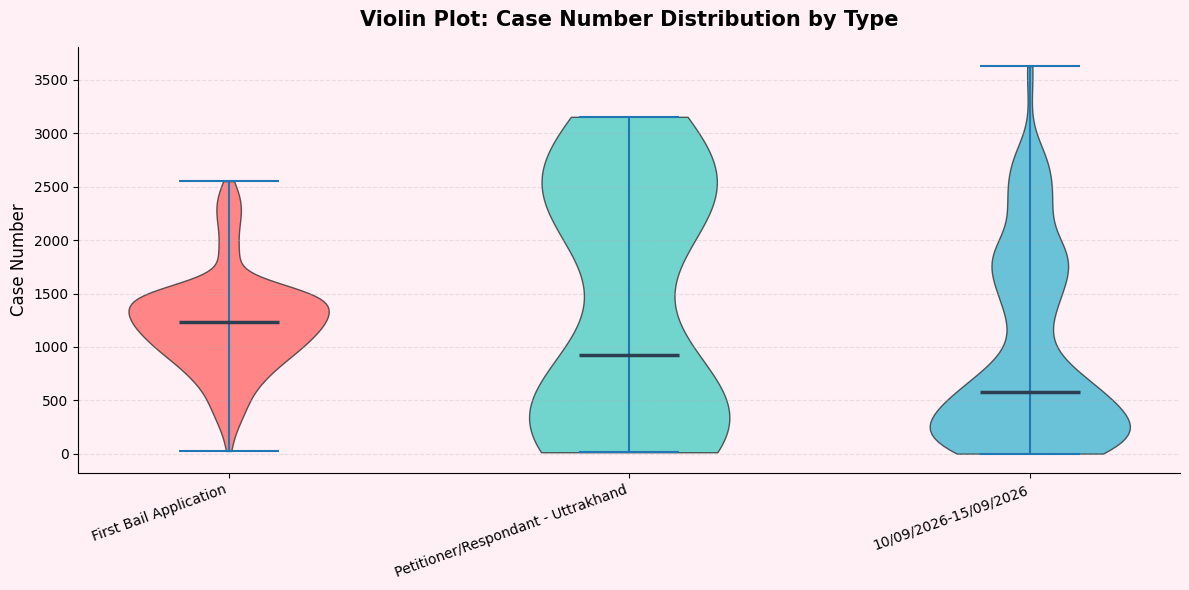

In [22]:

vio = df.dropna(subset=['Case Number Num']).copy()

fig, ax = plt.subplots(figsize=(12, 6))
parts = ax.violinplot(
    [vio[vio['Search Label']==l]['Case Number Num'].values for l in labels_ord],
    showmedians=True, showextrema=True
)
VIO_COLORS = ['#FF6B6B','#4ECDC4','#45B7D1','#96CEB4','#FFEAA7']
for i, (pc, color) in enumerate(zip(parts['bodies'], VIO_COLORS)):
    pc.set_facecolor(color)
    pc.set_edgecolor('#333')
    pc.set_alpha(0.8)
parts['cmedians'].set_color('#2C3E50')
parts['cmedians'].set_linewidth(2.5)
ax.set_xticks(range(1, len(labels_ord)+1))
ax.set_xticklabels(labels_ord, rotation=20, ha='right')
ax.set_ylabel('Case Number', fontsize=12)
ax.set_title('Violin Plot: Case Number Distribution by Type',
             fontsize=15, fontweight='bold', pad=15)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
fig.patch.set_facecolor('#FFF0F5')
ax.set_facecolor('#FFF0F5')
plt.tight_layout()
plt.show()